### Load Dataset

In [180]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Blues_d") 

In [181]:
# Load the dataset
df = pd.read_csv("../data/delhi_aqi.csv")

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Delhi,1/1/2015,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,472,Severe
1,Delhi,1/2/2015,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,454,Severe
2,Delhi,1/3/2015,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,143,Moderate
3,Delhi,1/4/2015,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,319,Very Poor
4,Delhi,1/5/2015,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,325,Very Poor


In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2009 entries, 0 to 2008
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        2009 non-null   str    
 1   Date        2009 non-null   str    
 2   PM2.5       2009 non-null   float64
 3   PM10        2009 non-null   float64
 4   NO          2009 non-null   float64
 5   NO2         2009 non-null   float64
 6   NOx         2009 non-null   float64
 7   NH3         2009 non-null   float64
 8   CO          2009 non-null   float64
 9   SO2         2009 non-null   float64
 10  O3          2009 non-null   float64
 11  Benzene     2009 non-null   float64
 12  Toluene     2009 non-null   float64
 13  AQI         2009 non-null   int64  
 14  AQI_Bucket  2009 non-null   str    
dtypes: float64(11), int64(1), str(3)
memory usage: 235.6 KB


In [185]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].min())
print(df['Date'].max())

2015-01-01 00:00:00
2020-07-01 00:00:00


### Data Understanding

Here's an explanation of the features present in the dataset:

| Feature    | Data Type | Missing Values | Description                          | Role in Analysis                                |
| ---------- | --------- | :------------: | ------------------------------------ | ----------------------------------------------- |
| `City`     | String    |              0 | City name (Delhi)                    | Spatial identifier - usually removed             |
| `Date`     | Datetime   |              0 | Date of observation                  | Time index (converted to datetime)              |
| `PM2.5`    | Float64   |              0 | Fine particulate matter ≤ 2.5 μm    | **TARGET VARIABLE** for forecasting             |
| `PM10`     | Float64   |              0 | Particulate matter ≤ 10 μm           | Air pollution indicator                         |
| `NO`       | Float64   |              0 | Nitrogen monoxide concentration      | Industrial/Traffic emission indicator           |
| `NO2`      | Float64   |              0 | Nitrogen dioxide concentration       | Traffic-related pollutant                       |
| `NOx`      | Float64   |              0 | Nitrogen oxides (NO + NO2)           | Aggregate nitrogen pollution metric             |
| `NH3`      | Float64   |              0 | Ammonia concentration                | Agricultural/Industrial emission indicator      |
| `CO`       | Float64   |              0 | Carbon monoxide concentration        | Combustion pollution indicator                  |
| `SO2`      | Float64   |              0 | Sulfur dioxide concentration         | Industrial emission indicator                   |
| `O3`       | Float64   |              0 | Ozone concentration                  | Secondary pollutant (photochemical reaction)    |
| `Benzene`  | Float64   |              0 | Benzene concentration                | Volatile organic compound (VOC)                 |
| `Toluene`  | Float64   |              0 | Toluene concentration                | Volatile organic compound (VOC)                 |
| `AQI`      | Int64    |              0 | Air Quality Index                    | Composite air quality metric (0-500+)           |
| `AQI_Bucket` | String  |              0 | AQI category (Good/Satisfactory/...) | Categorical AQI classification                  |

**Dataset description:**
* **Type**: Daily air quality observations
* **Location**: Delhi, India (Air Monitoring Station)
* **Size**: 2,009 records with 15 columns
* **Missing values**: 0 (complete dataset, no imputation needed)
* **Note**: NO3 and other chemical compounds measured as pollutant concentrations (μg/m³ or ppb)

In [209]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [186]:
# Statistical Summary
print("Statistical Summary of the Dataset:")
df.describe()

Statistical Summary of the Dataset:


,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
count,2009,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000
mean,2017-10-01 00:00:00,117.101215,233.949716,38.971533,50.769856,58.567023,41.957636,1.976053,16.026446,50.816546,3.544480,17.185042,258.632653
min,2015-01-01 00:00:00,10.240000,18.590000,3.570000,10.630000,0.000000,6.780000,0.000000,2.340000,6.940000,0.000000,0.000000,29.000000
25%,2016-05-17 00:00:00,57.080000,138.560000,15.900000,33.900000,31.150000,31.110000,0.910000,10.330000,34.050000,1.870000,6.650000,159.000000
50%,2017-10-01 00:00:00,94.490000,219.940000,27.200000,47.020000,52.750000,38.010000,1.240000,14.700000,43.290000,2.960000,12.750000,257.000000
75%,2019-02-15 00:00:00,152.990000,309.370000,50.720000,63.570000,75.360000,48.680000,1.870000,20.360000,59.880000,4.680000,23.200000,345.000000
max,2020-07-01 00:00:00,685.360000,796.880000,221.030000,162.500000,254.800000,166.700000,30.440000,71.560000,257.730000,20.640000,103.000000,716.000000
std,NaN,82.926225,120.039481,33.375798,22.690612,37.690350,17.286741,2.560253,8.061479,25.642551,2.431232,15.291597,119.883918


In [187]:
# Correlation Analysis
print("\nCorrelation Matrix:")
correlation = df.select_dtypes(include=[np.number]).corr()
correlation


Correlation Matrix:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
PM2.5,1.000000,0.838732,0.668167,0.646748,0.487765,0.584104,0.171724,0.331168,0.266755,0.698466,0.359590,0.882312
PM10,0.838732,1.000000,0.688609,0.688587,0.464999,0.507110,0.126453,0.461532,0.301719,0.633243,0.301025,0.839608
NO,0.668167,0.688609,1.000000,0.775502,0.573594,0.459174,0.022127,0.503993,0.214957,0.655923,0.402735,0.639866
NO2,0.646748,0.688587,0.775502,1.000000,0.580645,0.480095,0.030945,0.584659,0.419627,0.563314,0.218902,0.659727
NOx,0.487765,0.464999,0.573594,0.580645,1.000000,0.321408,0.172149,0.202826,0.479102,0.620433,0.397077,0.559927
NH3,0.584104,0.507110,0.459174,0.480095,0.321408,1.000000,0.335401,0.098542,0.144355,0.433935,0.113823,0.520954
CO,0.171724,0.126453,0.022127,0.030945,0.172149,0.335401,1.000000,-0.166345,-0.011188,0.206362,0.007877,0.283236
SO2,0.331168,0.461532,0.503993,0.584659,0.202826,0.098542,-0.166345,1.000000,0.308933,0.302252,0.088055,0.345638
O3,0.266755,0.301719,0.214957,0.419627,0.479102,0.144355,-0.011188,0.308933,1.000000,0.253808,-0.082462,0.341650
Benzene,0.698466,0.633243,0.655923,0.563314,0.620433,0.433935,0.206362,0.302252,0.253808,1.000000,0.632060,0.672799


### Exploratory Data Analysis

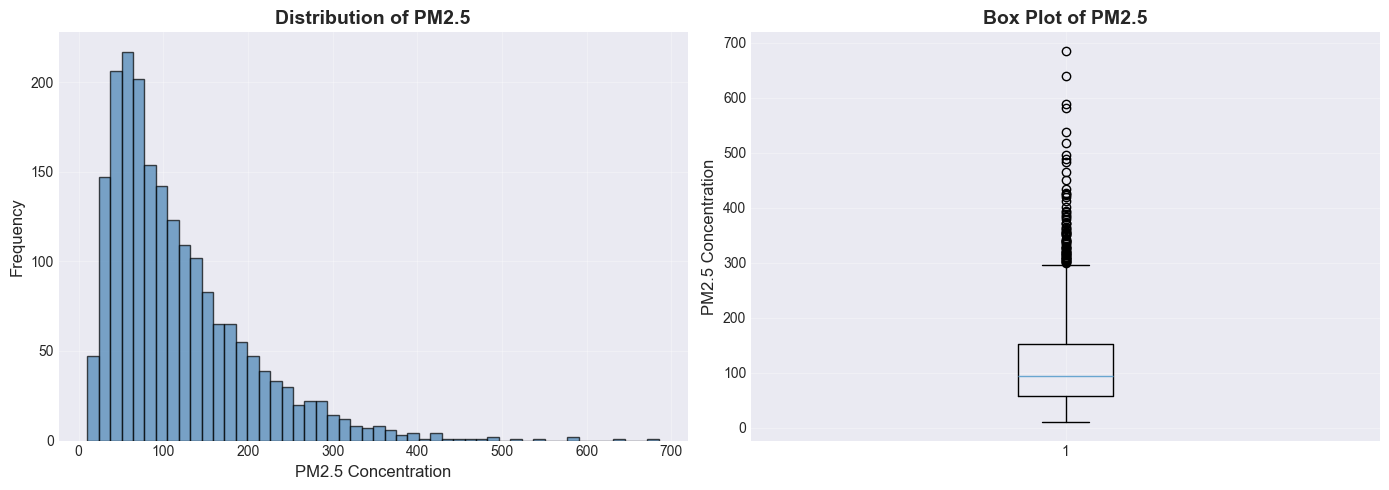

PM2.5 - Skewness: 1.705, Kurtosis: 4.504


In [189]:
# Distribution of PM2.5 (Target Variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['PM2.5'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('PM2.5 Concentration', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of PM2.5', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['PM2.5'], vert=True)
axes[1].set_ylabel('PM2.5 Concentration', fontsize=12)
axes[1].set_title('Box Plot of PM2.5', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PM2.5 - Skewness: {df['PM2.5'].skew():.3f}, Kurtosis: {df['PM2.5'].kurtosis():.3f}")

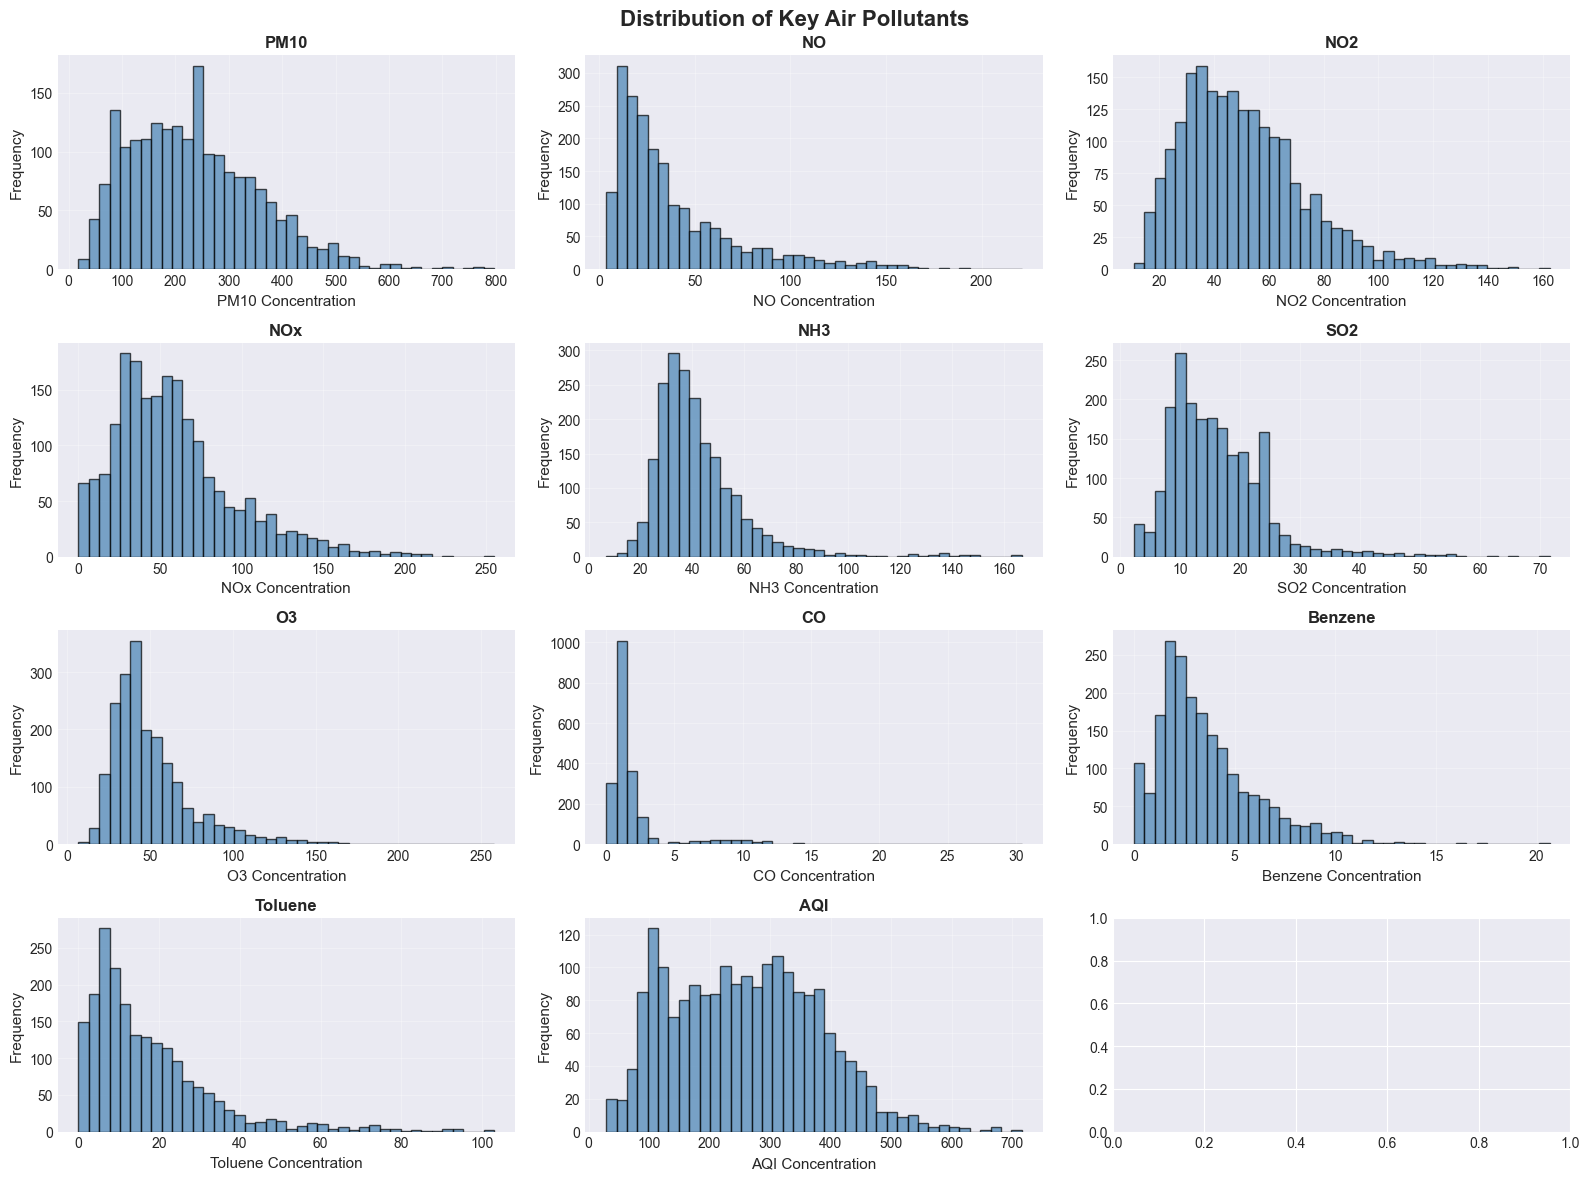

In [208]:
# Distribution of Key Pollutants
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
fig.suptitle('Distribution of Key Air Pollutants', fontsize=16, fontweight='bold')

pollutants = ['PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'O3', 'CO', 'Benzene', 'Toluene', 'AQI']
for idx, ax in enumerate(axes.flat):
    if idx < len(pollutants):
        pollutant = pollutants[idx]
        ax.hist(df[pollutant], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_xlabel(f'{pollutant} Concentration', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{pollutant}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

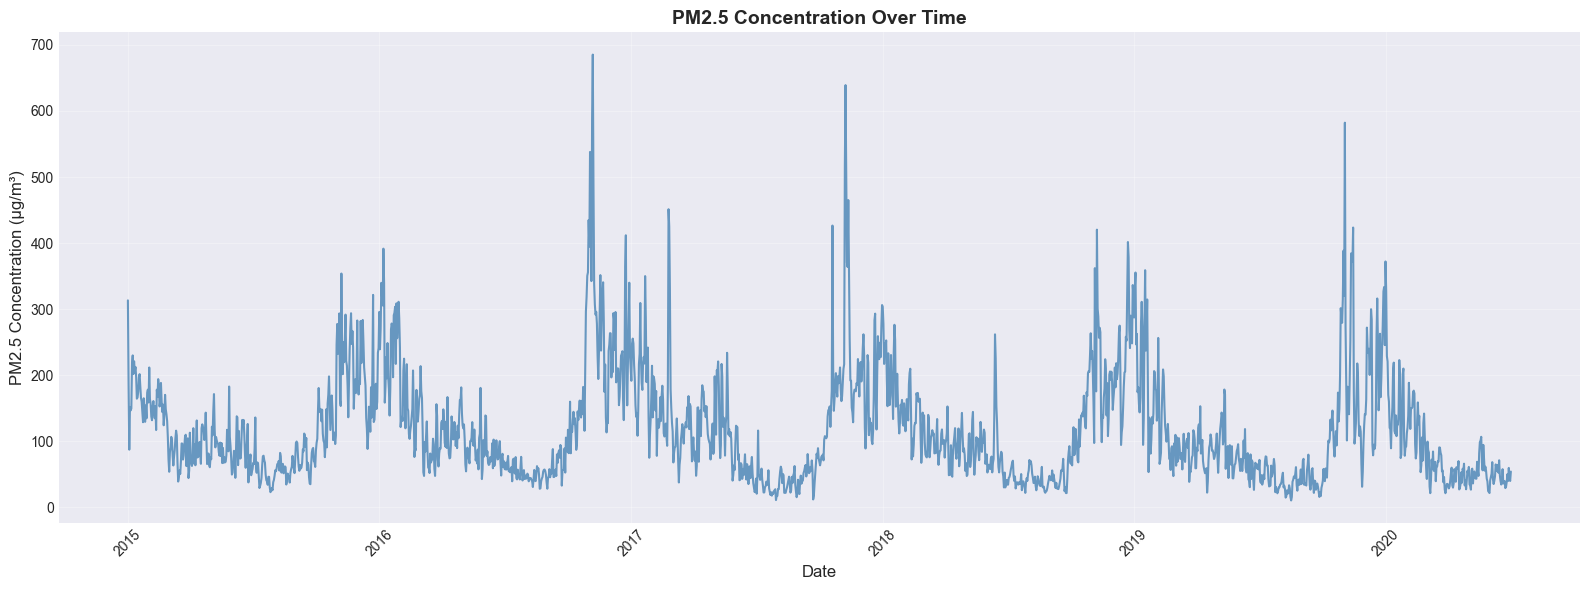

In [191]:
# Time Series Trend - PM2.5 Over Time
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['PM2.5'], linewidth=1.5, color='steelblue', alpha=0.8)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
ax.set_title('PM2.5 Concentration Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

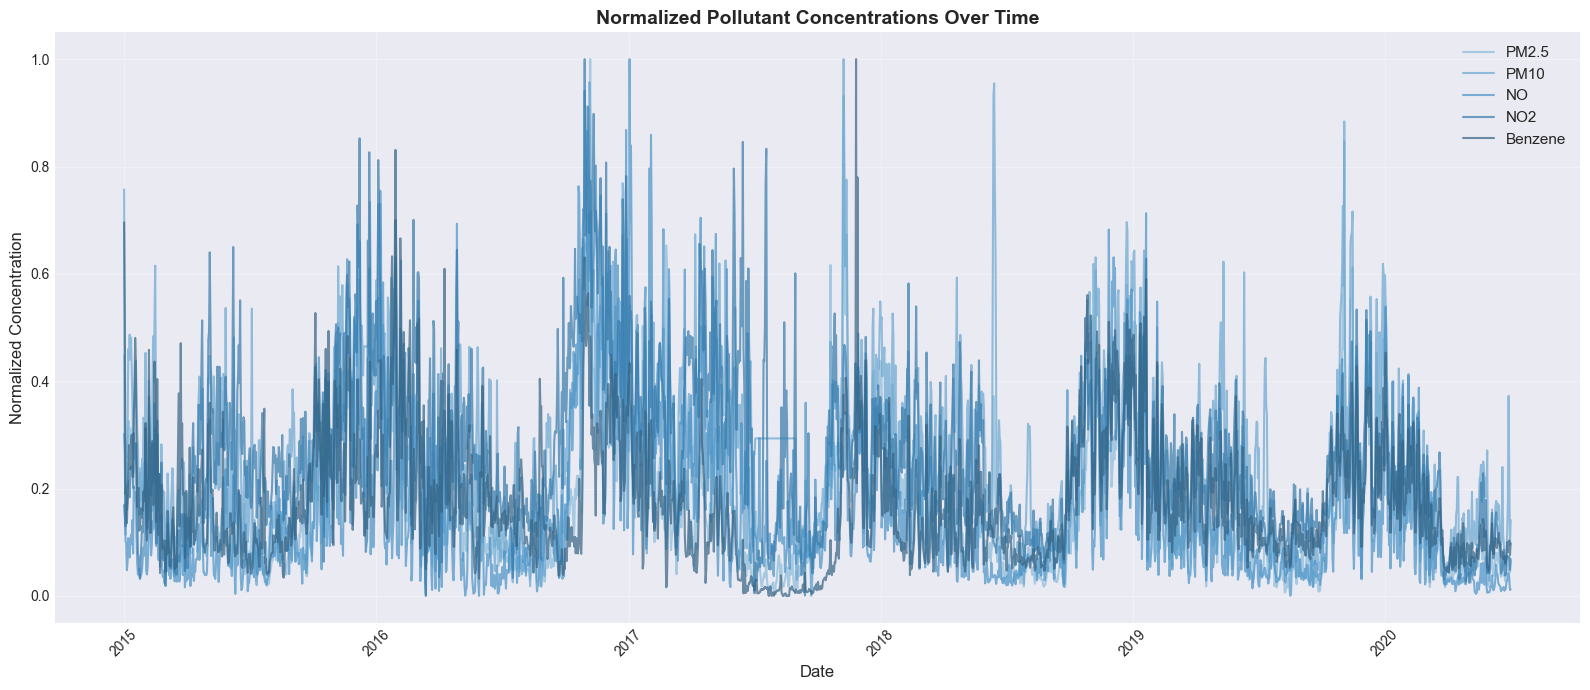

In [192]:
# Time Series of Multiple Pollutants
fig, ax = plt.subplots(figsize=(16, 7))

# Normalize for better comparison
pollutants_to_plot = ['PM2.5', 'PM10', 'NO', 'NO2', 'Benzene']
for pollutant in pollutants_to_plot:
    normalized = (df[pollutant] - df[pollutant].min()) / (df[pollutant].max() - df[pollutant].min())
    ax.plot(df['Date'], normalized, label=pollutant, linewidth=1.5, alpha=0.7)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Concentration', fontsize=12)
ax.set_title('Normalized Pollutant Concentrations Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [193]:
# Extract temporal features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

print("Temporal features extracted:")
print(f"  Years: {sorted(df['Year'].unique())}")
print(f"  Months: {sorted(df['Month'].unique())}")
print(f"  Day of Week: 0=Monday, 1=Tuesday, ..., 6=Sunday")
print(f"  Data timespan: {df['Date'].min().date()} to {df['Date'].max().date()}")

Temporal features extracted:
  Years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
  Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  Day of Week: 0=Monday, 1=Tuesday, ..., 6=Sunday
  Data timespan: 2015-01-01 to 2020-07-01



Monthly PM2.5 Statistics:
             mean         std    min     max  count
Month                                              
1      197.485430   69.877079  53.25  391.54    186
2      141.975529   53.073517  47.18  451.25    170
3       87.573871   31.707455  21.23  213.62    186
4       90.932222   36.493279  22.14  184.69    180
5       92.209946   40.201837  21.51  233.82    186
6       69.810111   32.453353  22.98  261.77    180
7       46.417628   18.666456  10.88  135.92    156
8       42.827548   14.629659  10.24   82.27    155
9       55.345000   22.753604  11.81  111.58    150
10     140.911935   69.169478  33.92  434.92    155
11     238.245200  115.291995  31.03  685.36    150
12     208.100000   69.610054  78.59  411.80    155


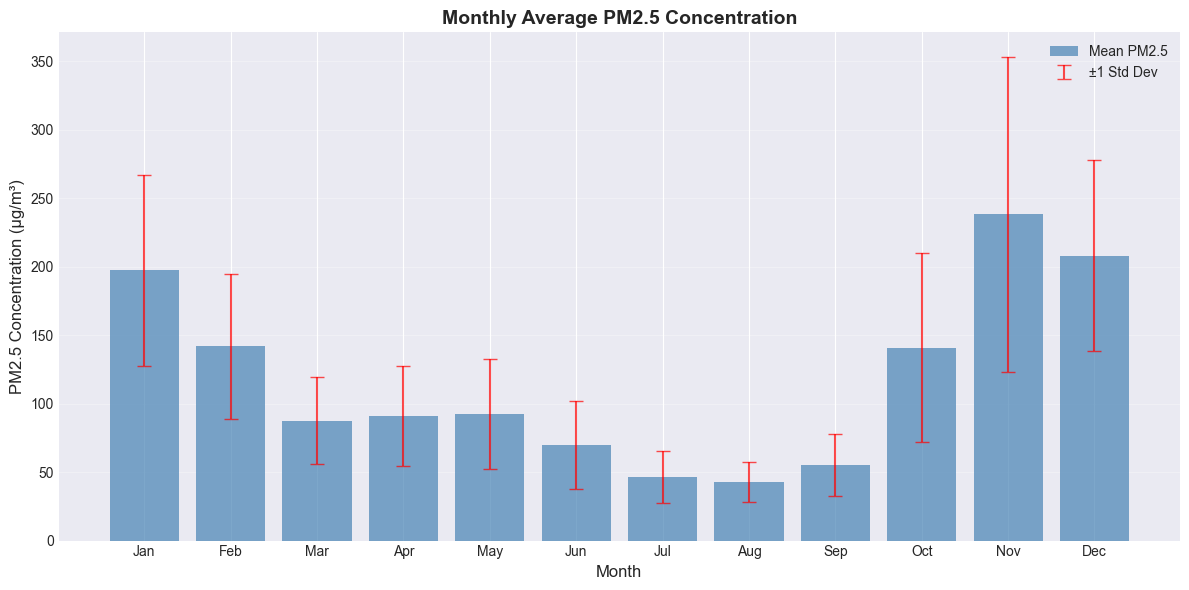

In [194]:
# Monthly Analysis - PM2.5 Average by Month
monthly_stats = df.groupby('Month')['PM2.5'].agg(['mean', 'std', 'min', 'max', 'count'])
print("\nMonthly PM2.5 Statistics:")
print(monthly_stats)

# Visualize monthly pattern
fig, ax = plt.subplots(figsize=(12, 6))
monthly_mean = df.groupby('Month')['PM2.5'].mean()
monthly_std = df.groupby('Month')['PM2.5'].std()

ax.bar(monthly_mean.index, monthly_mean.values, color='steelblue', alpha=0.7, label='Mean PM2.5')
ax.errorbar(monthly_mean.index, monthly_mean.values, yerr=monthly_std.values, 
            fmt='none', color='red', alpha=0.7, capsize=5, label='±1 Std Dev')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
ax.set_title('Monthly Average PM2.5 Concentration', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Yearly PM2.5 Statistics:
            mean        std    min     max  count
Year                                             
2015  117.340822  63.130632  22.82  353.86    365
2016  138.502842  99.959144  28.01  685.36    366
2017  124.524904  89.637823  10.88  639.19    365
2018  115.019397  75.767700  21.45  420.30    365
2019  108.501479  85.545633  10.24  582.28    365
2020   80.317978  55.900607  21.23  372.14    183


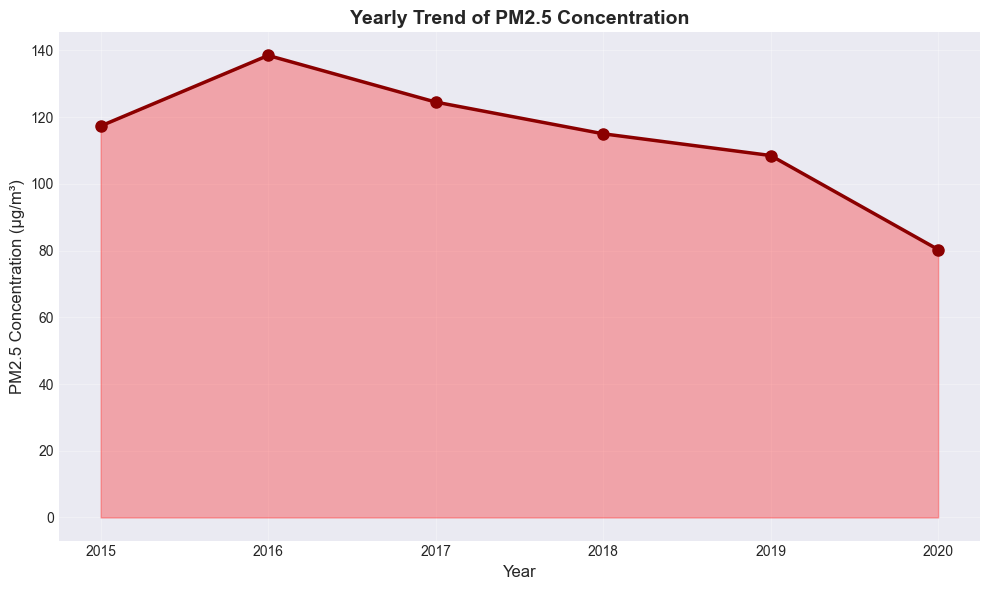

In [195]:
# Yearly Analysis
yearly_stats = df.groupby('Year')['PM2.5'].agg(['mean', 'std', 'min', 'max', 'count'])
print("\nYearly PM2.5 Statistics:")
print(yearly_stats)

# Visualize yearly trend
fig, ax = plt.subplots(figsize=(10, 6))
yearly_mean = df.groupby('Year')['PM2.5'].mean()
ax.plot(yearly_mean.index, yearly_mean.values, marker='o', linewidth=2.5, 
        markersize=8, color='darkred', label='Mean PM2.5')
ax.fill_between(yearly_mean.index, yearly_mean.values, alpha=0.3, color='red')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
ax.set_title('Yearly Trend of PM2.5 Concentration', fontsize=14, fontweight='bold')
ax.set_xticks(yearly_mean.index)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Day of Week PM2.5 Statistics (0=Mon, 6=Sun):
                 mean        std    min     max  count
DayOfWeek                                             
0          114.623484  79.296951  17.10  488.57    287
1          115.780662  78.473501  15.23  517.93    287
2          117.341220  83.126641  20.17  639.19    287
3          120.330314  84.883647  21.74  495.90    287
4          118.876132  82.658325  11.81  451.25    287
5          116.831150  84.450340  10.24  588.39    287
6          115.925540  87.936900  10.88  685.36    287


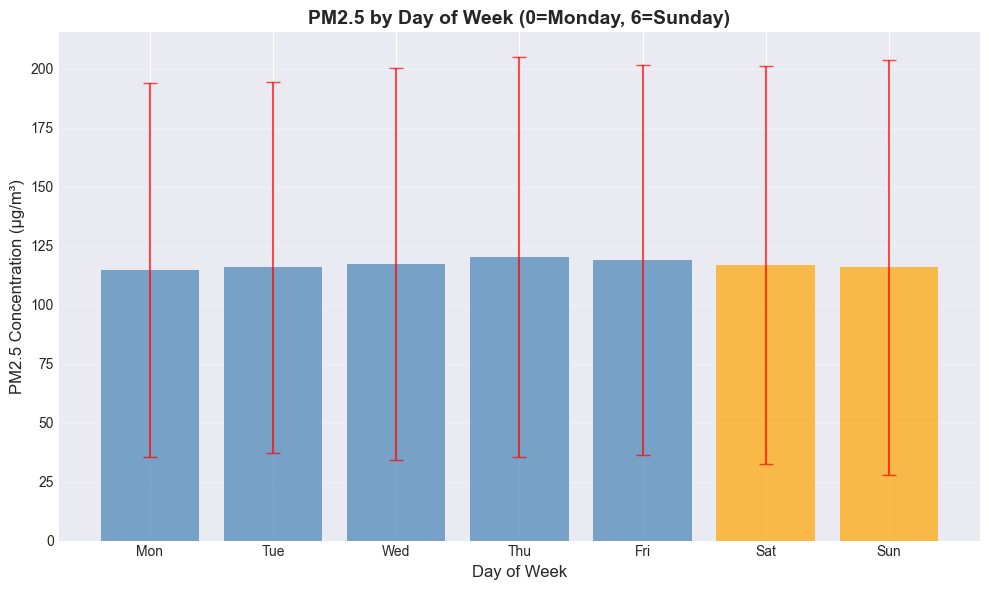

In [196]:
# Day of Week Analysis
dow_stats = df.groupby('DayOfWeek')['PM2.5'].agg(['mean', 'std', 'min', 'max', 'count'])
print("\nDay of Week PM2.5 Statistics (0=Mon, 6=Sun):")
print(dow_stats)

# Visualize day of week pattern
fig, ax = plt.subplots(figsize=(10, 6))
dow_mean = df.groupby('DayOfWeek')['PM2.5'].mean()
dow_std = df.groupby('DayOfWeek')['PM2.5'].std()
colors = ['steelblue']*5 + ['orange']*2  # Different colors for weekday vs weekend

ax.bar(dow_mean.index, dow_mean.values, color=colors, alpha=0.7)
ax.errorbar(dow_mean.index, dow_mean.values, yerr=dow_std.values, 
            fmt='none', color='red', alpha=0.7, capsize=5)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
ax.set_title('PM2.5 by Day of Week (0=Monday, 6=Sunday)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 7))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Quarterly PM2.5 Statistics:
               mean        std    min     max  count
Quarter                                             
1        142.355849  70.499632  21.23  451.25    542
2         84.404158  37.909778  21.51  261.77    546
3         48.115336  19.601065  10.24  135.92    461
4        195.290500  95.931382  31.03  685.36    460


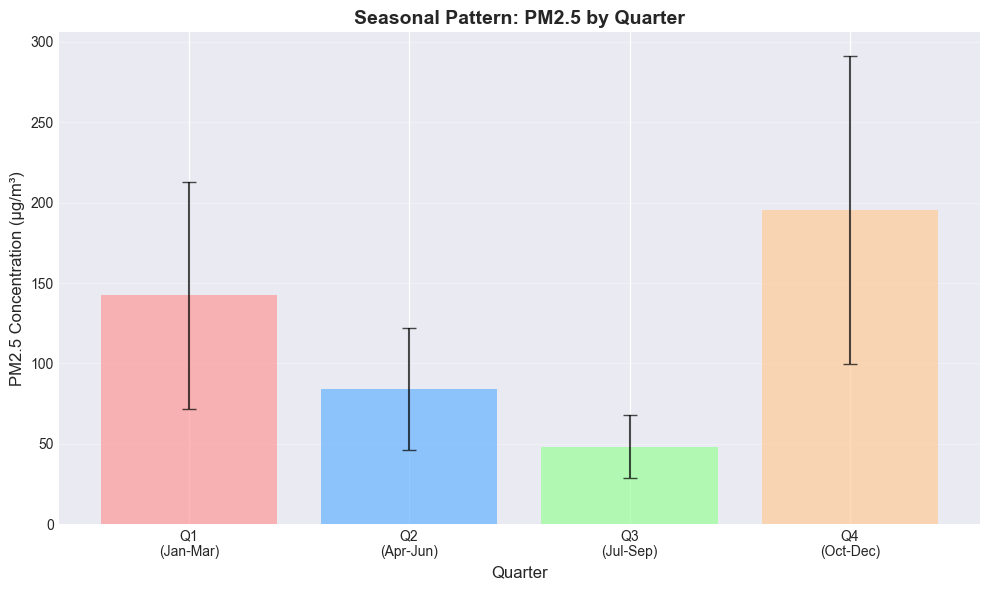

In [197]:
# Quarterly Analysis
quarter_stats = df.groupby('Quarter')['PM2.5'].agg(['mean', 'std', 'min', 'max', 'count'])
print("\nQuarterly PM2.5 Statistics:")
print(quarter_stats)

# Visualize quarterly pattern
fig, ax = plt.subplots(figsize=(10, 6))
quarter_mean = df.groupby('Quarter')['PM2.5'].mean()
quarter_std = df.groupby('Quarter')['PM2.5'].std()

ax.bar(quarter_mean.index, quarter_mean.values, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'], alpha=0.7)
ax.errorbar(quarter_mean.index, quarter_mean.values, yerr=quarter_std.values, 
            fmt='none', color='black', alpha=0.7, capsize=5)
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
ax.set_title('Seasonal Pattern: PM2.5 by Quarter', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Q1\n(Jan-Mar)', 'Q2\n(Apr-Jun)', 'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dec)'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Top Correlations with PM2.5:
PM2.5      1.000000
AQI        0.882312
PM10       0.838732
Benzene    0.698466
NO         0.668167
NO2        0.646748
NH3        0.584104
NOx        0.487765
Toluene    0.359590
SO2        0.331168
O3         0.266755
CO         0.171724
Name: PM2.5, dtype: float64


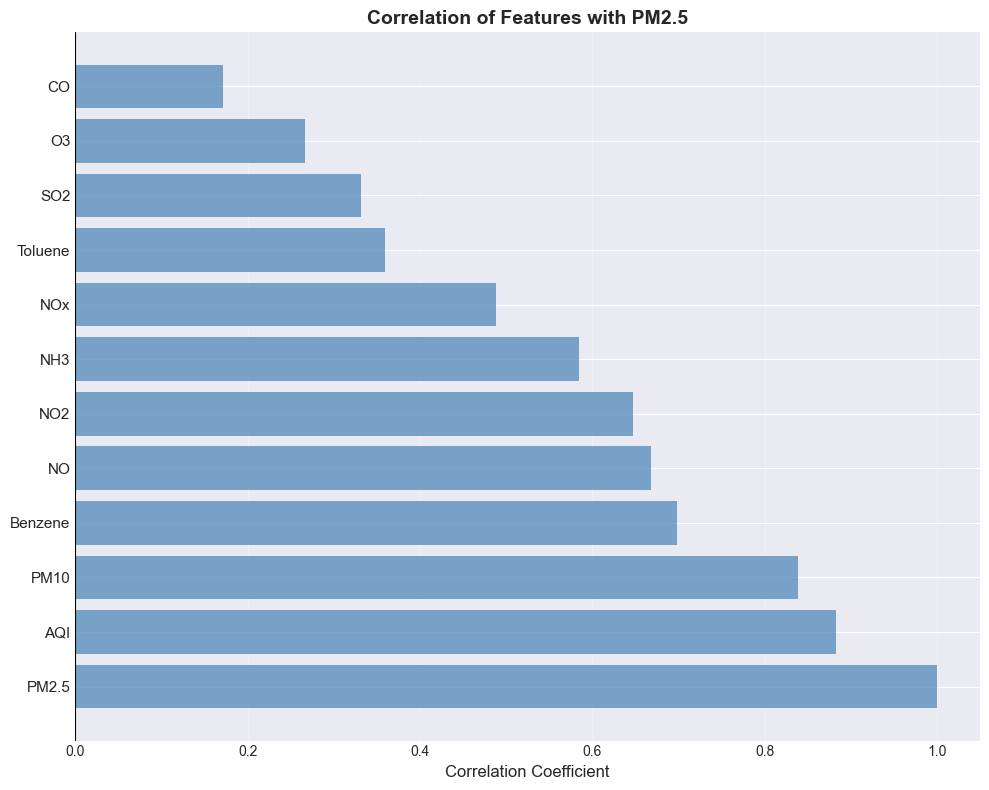

In [207]:
# Top Correlations with PM2.5 (Target Variable)
pm25_correlation = correlation['PM2.5'].sort_values(ascending=False)
print("\nTop Correlations with PM2.5:")
print(pm25_correlation)

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if x > 0 else 'red' for x in pm25_correlation.values]
ax.barh(range(len(pm25_correlation)), pm25_correlation.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(pm25_correlation)))
ax.set_yticklabels(pm25_correlation.index, fontsize=11)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Correlation of Features with PM2.5', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

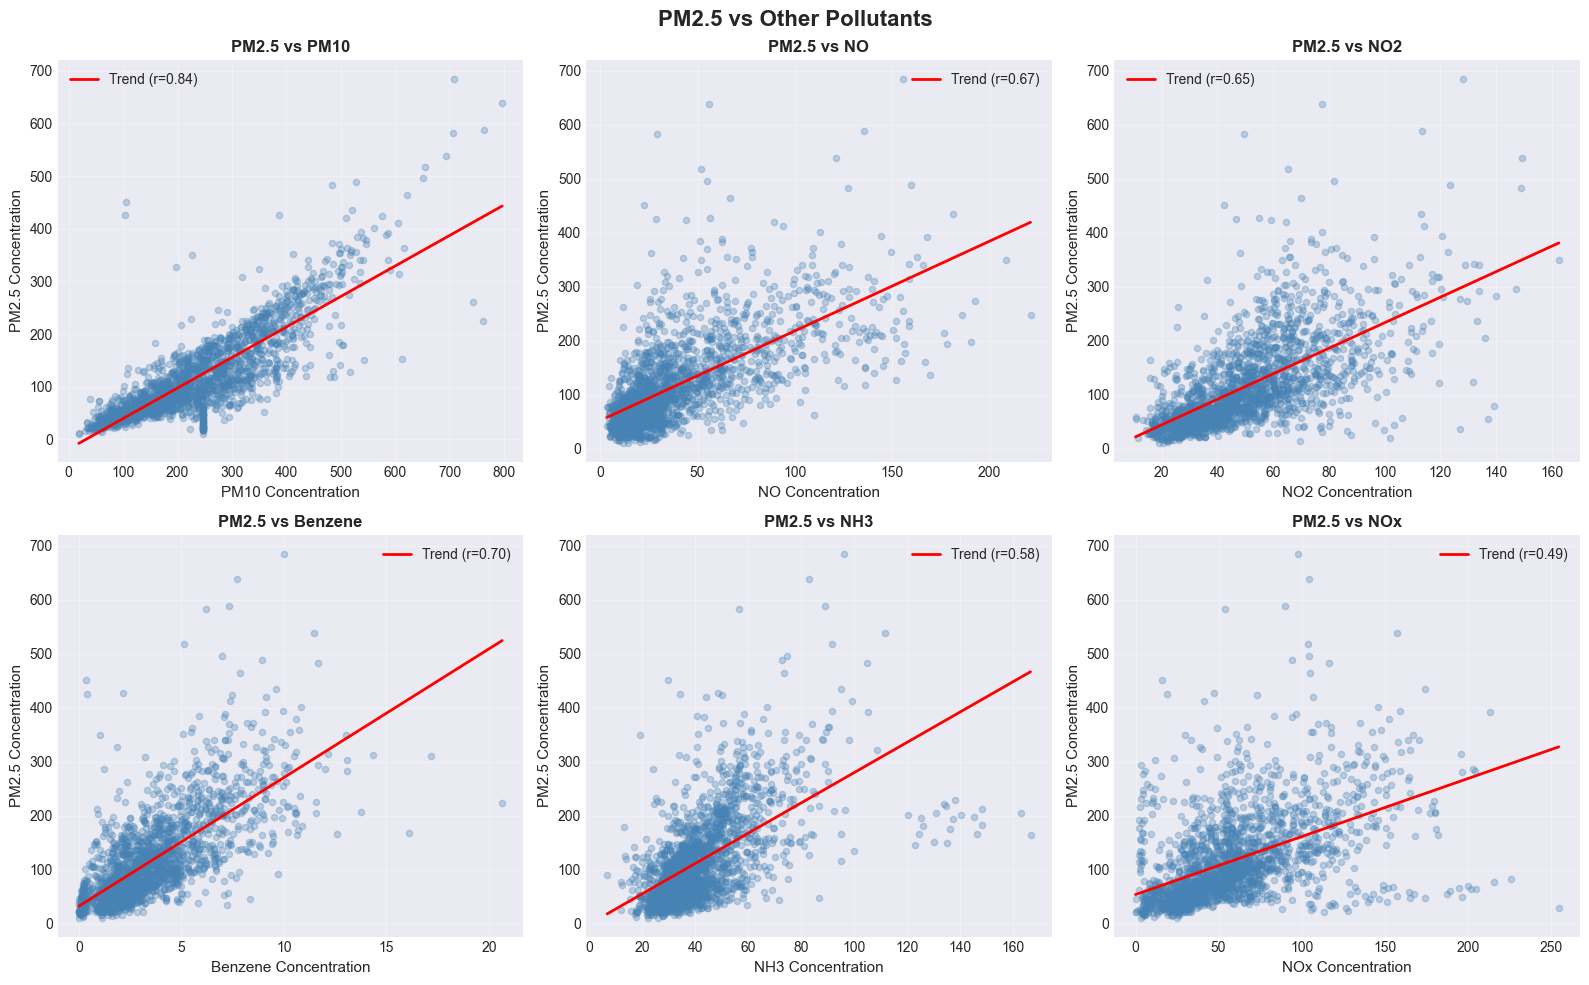

In [199]:
# Scatter plot: PM2.5 vs other key pollutants
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PM2.5 vs Other Pollutants', fontsize=16, fontweight='bold')

pollutants = ['PM10', 'NO', 'NO2', 'Benzene', 'NH3', 'NOx']
for idx, (ax, pollutant) in enumerate(zip(axes.flat, pollutants)):
    ax.scatter(df[pollutant], df['PM2.5'], alpha=0.3, s=20, color='steelblue')
    
    # Add trend line
    z = np.polyfit(df[pollutant], df['PM2.5'], 1)
    p = np.poly1d(z)
    ax.plot(df[pollutant].sort_values(), p(df[pollutant].sort_values()), 
            "r-", linewidth=2, label=f'Trend (r={correlation.loc["PM2.5", pollutant]:.2f})')
    
    ax.set_xlabel(f'{pollutant} Concentration', fontsize=11)
    ax.set_ylabel('PM2.5 Concentration', fontsize=11)
    ax.set_title(f'PM2.5 vs {pollutant}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

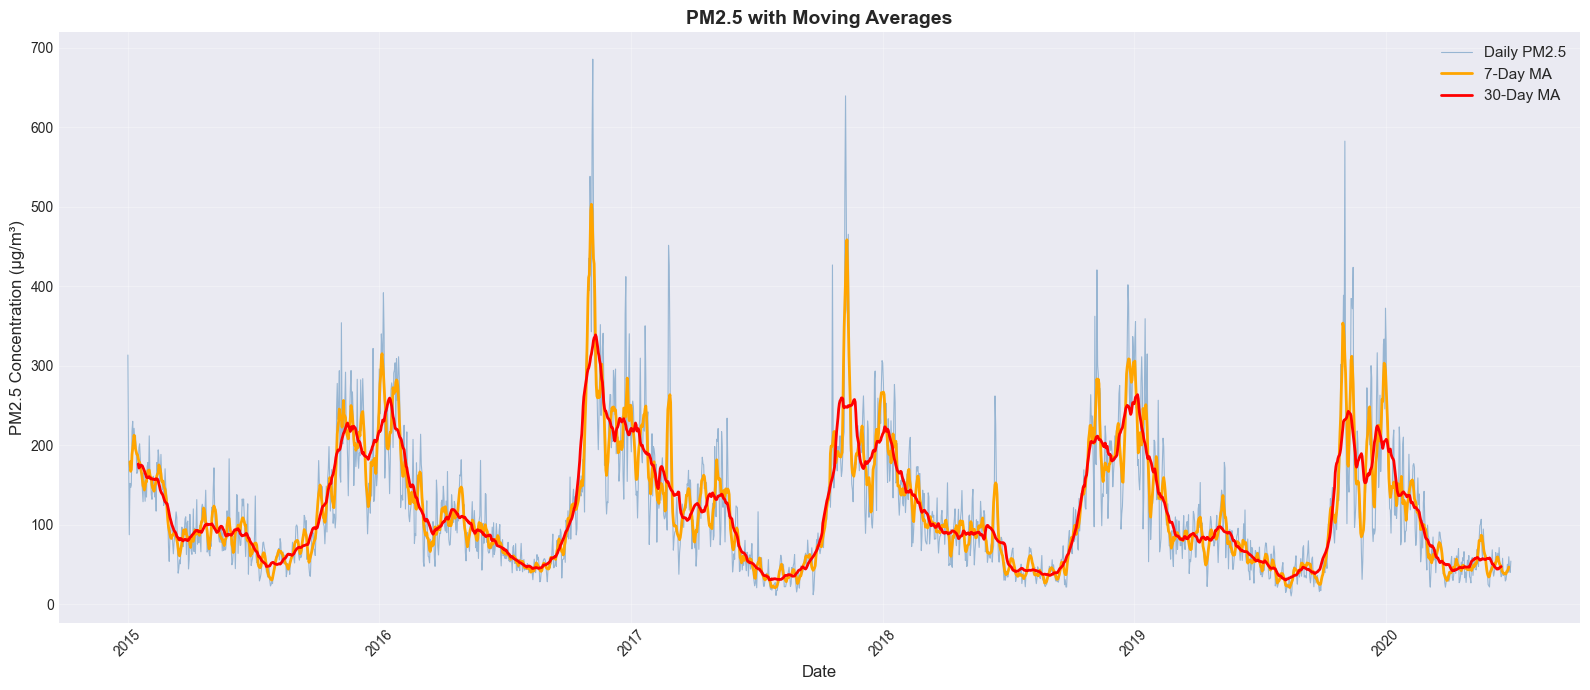

In [200]:
# Rolling Statistics - Moving Averages
df_sorted = df.sort_values('Date').reset_index(drop=True)
df_sorted['PM2.5_MA7'] = df_sorted['PM2.5'].rolling(window=7, center=True).mean()
df_sorted['PM2.5_MA30'] = df_sorted['PM2.5'].rolling(window=30, center=True).mean()

# Plot with moving averages
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df_sorted['Date'], df_sorted['PM2.5'], linewidth=0.8, alpha=0.5, label='Daily PM2.5', color='steelblue')
ax.plot(df_sorted['Date'], df_sorted['PM2.5_MA7'], linewidth=2, label='7-Day MA', color='orange')
ax.plot(df_sorted['Date'], df_sorted['PM2.5_MA30'], linewidth=2, label='30-Day MA', color='red')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12)
ax.set_title('PM2.5 with Moving Averages', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

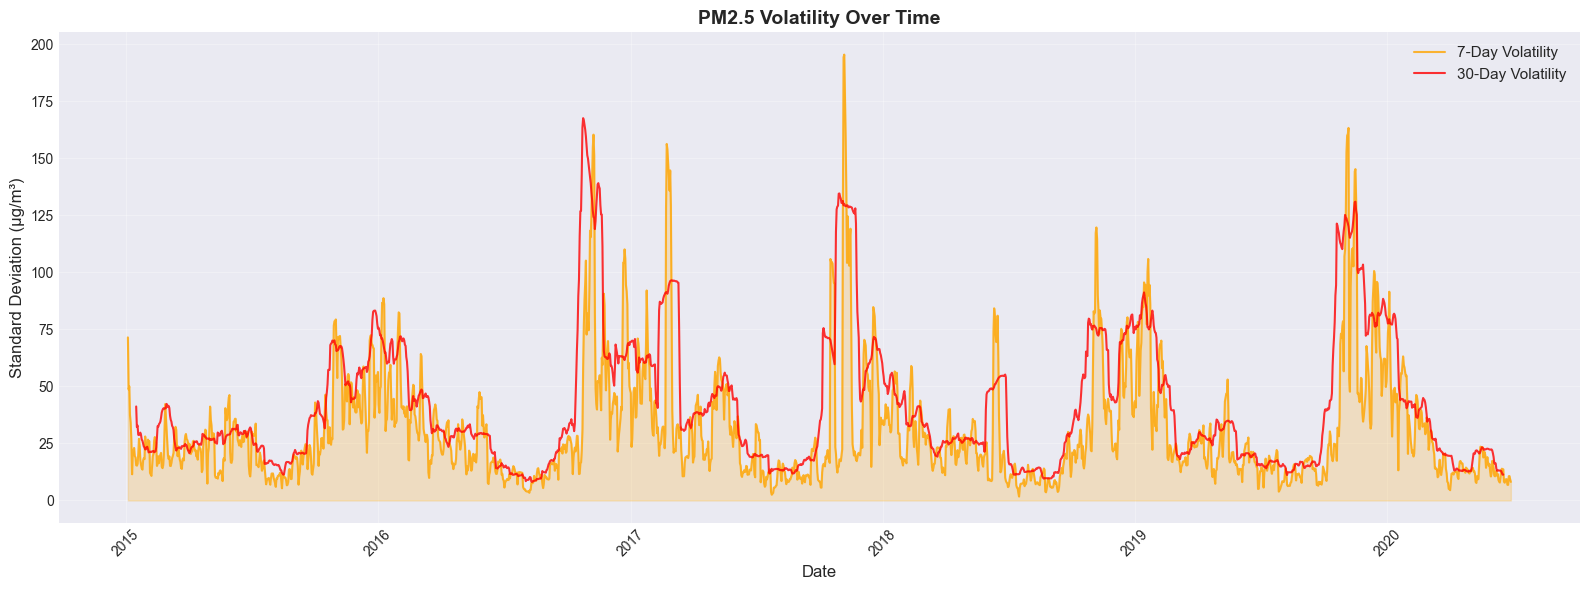

In [201]:
# Volatility Analysis - Rolling Standard Deviation
df_sorted['PM2.5_Std7'] = df_sorted['PM2.5'].rolling(window=7, center=True).std()
df_sorted['PM2.5_Std30'] = df_sorted['PM2.5'].rolling(window=30, center=True).std()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_sorted['Date'], df_sorted['PM2.5_Std7'], linewidth=1.5, label='7-Day Volatility', color='orange', alpha=0.8)
ax.plot(df_sorted['Date'], df_sorted['PM2.5_Std30'], linewidth=1.5, label='30-Day Volatility', color='red', alpha=0.8)
ax.fill_between(df_sorted['Date'], df_sorted['PM2.5_Std7'], alpha=0.2, color='orange')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Standard Deviation (μg/m³)', fontsize=12)
ax.set_title('PM2.5 Volatility Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


AQI Bucket Distribution:
AQI_Bucket
Poor            542
Moderate        525
Very Poor       520
Severe          239
Satisfactory    158
Good             25
Name: count, dtype: int64

AQI Bucket Percentages:
AQI_Bucket
Poor            26.978596
Moderate        26.132404
Very Poor       25.883524
Severe          11.896466
Satisfactory     7.864609
Good             1.244400
Name: proportion, dtype: float64


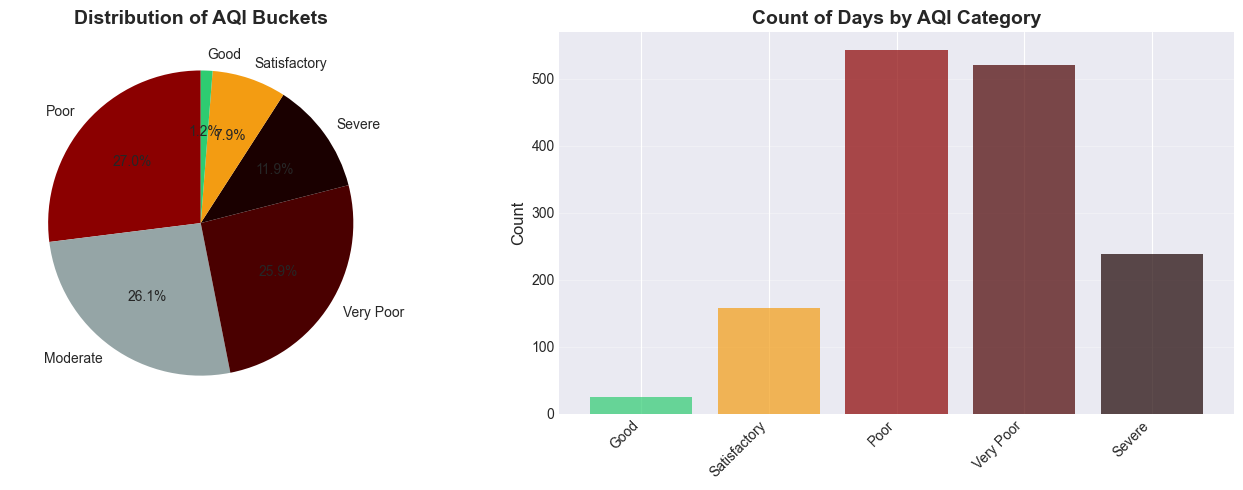

In [202]:
# AQI Bucket Distribution Analysis
print("\nAQI Bucket Distribution:")
aqi_dist = df['AQI_Bucket'].value_counts()
print(aqi_dist)
print(f"\nAQI Bucket Percentages:")
print(df['AQI_Bucket'].value_counts(normalize=True) * 100)

# Visualize AQI Bucket
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_aqi = {'Good': '#2ecc71', 'Satisfactory': '#f39c12', 'Moderately Polluted': '#e74c3c', 
              'Poor': '#8b0000', 'Very Poor': '#4a0000', 'Severe': '#1a0000'}
colors = [colors_aqi.get(label, '#95a5a6') for label in aqi_dist.index]
axes[0].pie(aqi_dist.values, labels=aqi_dist.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Distribution of AQI Buckets', fontsize=14, fontweight='bold')

# Bar chart
aqi_order = ['Good', 'Satisfactory', 'Moderately Polluted', 'Poor', 'Very Poor', 'Severe']
aqi_dist_ordered = df['AQI_Bucket'].value_counts().reindex([x for x in aqi_order if x in df['AQI_Bucket'].unique()])
axes[1].bar(range(len(aqi_dist_ordered)), aqi_dist_ordered.values, 
            color=[colors_aqi.get(label, '#95a5a6') for label in aqi_dist_ordered.index], alpha=0.7)
axes[1].set_xticks(range(len(aqi_dist_ordered)))
axes[1].set_xticklabels(aqi_dist_ordered.index, rotation=45, ha='right')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Count of Days by AQI Category', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

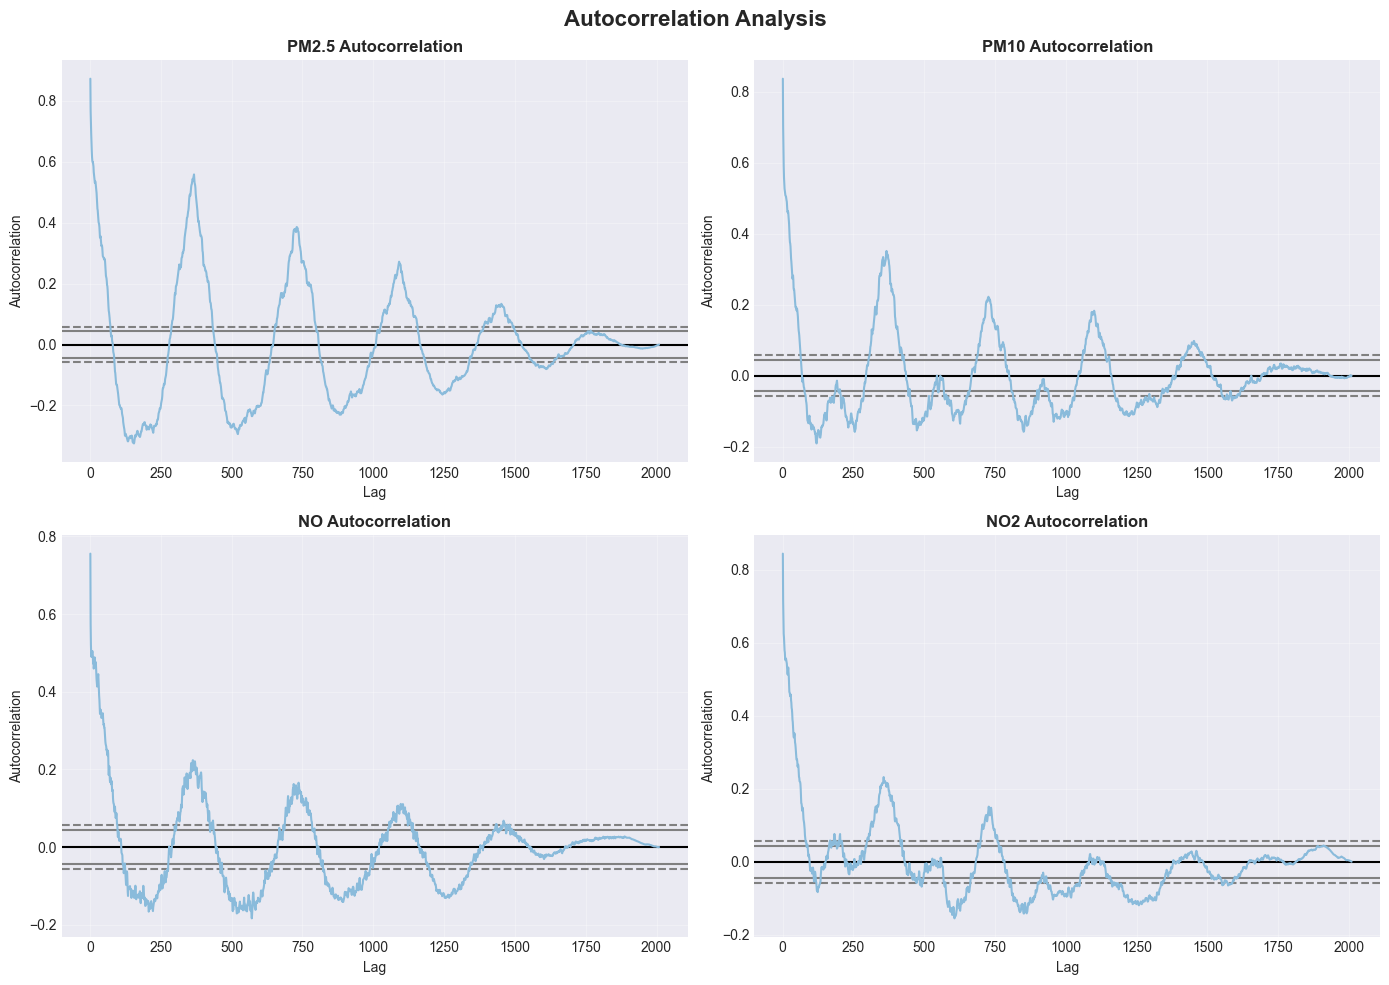

In [203]:
# Autocorrelation Analysis
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Autocorrelation Analysis', fontsize=16, fontweight='bold')

# PM2.5
axes[0, 0].set_title('PM2.5 Autocorrelation', fontsize=12, fontweight='bold')
autocorrelation_plot(df_sorted['PM2.5'].dropna(), ax=axes[0, 0])
axes[0, 0].grid(True, alpha=0.3)

# PM10
axes[0, 1].set_title('PM10 Autocorrelation', fontsize=12, fontweight='bold')
autocorrelation_plot(df_sorted['PM10'].dropna(), ax=axes[0, 1])
axes[0, 1].grid(True, alpha=0.3)

# NO2
axes[1, 0].set_title('NO Autocorrelation', fontsize=12, fontweight='bold')
autocorrelation_plot(df_sorted['NO'].dropna(), ax=axes[1, 0])
axes[1, 0].grid(True, alpha=0.3)

# SO2
axes[1, 1].set_title('NO2 Autocorrelation', fontsize=12, fontweight='bold')
autocorrelation_plot(df_sorted['NO2'].dropna(), ax=axes[1, 1])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Pollutant Index Statistics (Weighted Composite Index):
  Min: 0.0444
  Max: 0.8556
  Mean: 0.2239
  Median: 0.1953
  Std Dev: 0.1215


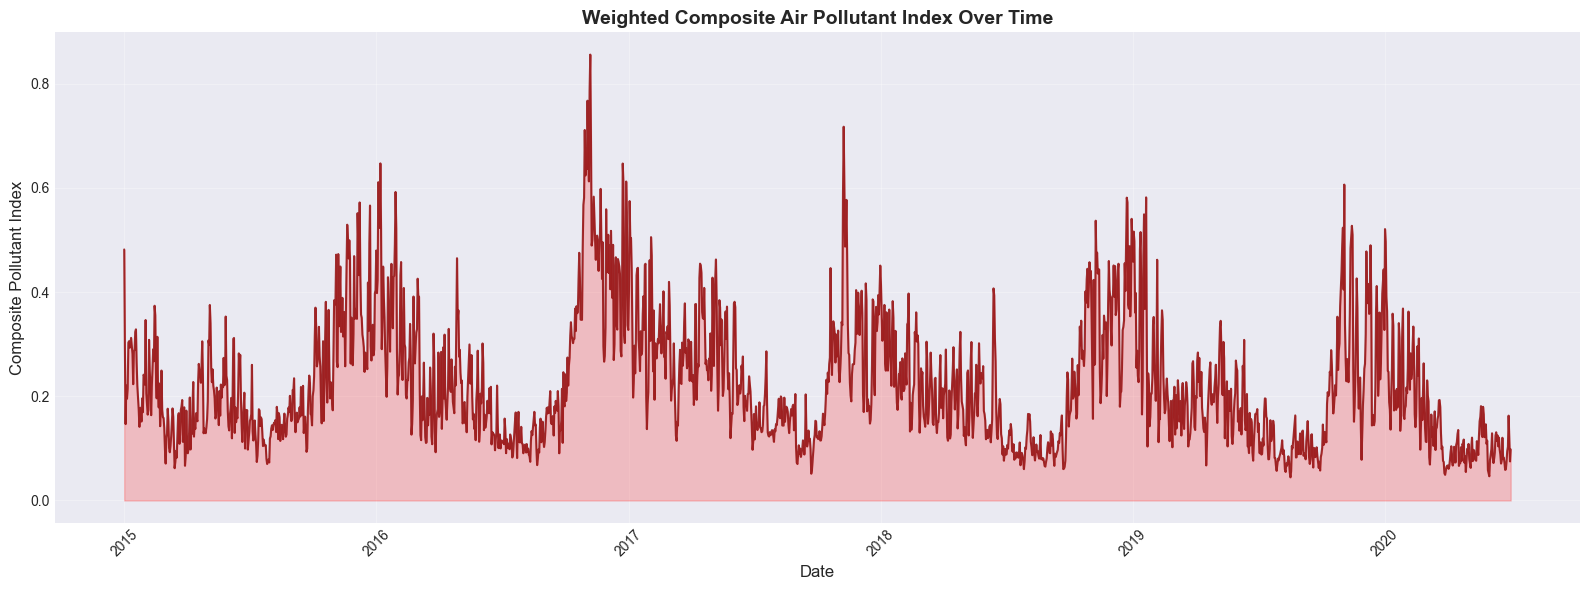

In [204]:
# Combined Pollutant Index Analysis
df['Pollutant_Index'] = (
    (df['PM2.5'] / df['PM2.5'].max()) * 0.35 +
    (df['PM10'] / df['PM10'].max()) * 0.25 +
    (df['NO'] / df['NO'].max()) * 0.20 +
    (df['NO2'] / df['NO2'].max()) * 0.15 +
    (df['Benzene'] / df['Benzene'].max()) * 0.05
)

print("\nPollutant Index Statistics (Weighted Composite Index):")
print(f"  Min: {df['Pollutant_Index'].min():.4f}")
print(f"  Max: {df['Pollutant_Index'].max():.4f}")
print(f"  Mean: {df['Pollutant_Index'].mean():.4f}")
print(f"  Median: {df['Pollutant_Index'].median():.4f}")
print(f"  Std Dev: {df['Pollutant_Index'].std():.4f}")

# Visualize composite index
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Pollutant_Index'], linewidth=1.5, color='darkred', alpha=0.8, label='Pollutant Index')
ax.fill_between(df['Date'], df['Pollutant_Index'], alpha=0.2, color='red')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Composite Pollutant Index', fontsize=12)
ax.set_title('Weighted Composite Air Pollutant Index Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [205]:
# Extreme Values Analysis
print("\n" + "="*60)
print("EXTREME VALUES ANALYSIS")
print("="*60)

for pollutant in ['PM2.5', 'PM10', 'NO', 'NO2', 'Benzene', 'NH3']:
    print(f"\n{pollutant}:")
    print(f"  Top 5 Maximum Values:")
    top_max = df.nlargest(5, pollutant)[['Date', pollutant]].reset_index(drop=True)
    for idx, row in top_max.iterrows():
        print(f"    {row['Date']}: {row[pollutant]:.2f}")
    
    print(f"  Top 5 Minimum Values:")
    top_min = df.nsmallest(5, pollutant)[['Date', pollutant]].reset_index(drop=True)
    for idx, row in top_min.iterrows():
        print(f"    {row['Date']}: {row[pollutant]:.2f}")


EXTREME VALUES ANALYSIS

PM2.5:
  Top 5 Maximum Values:
    2016-11-06 00:00:00: 685.36
    2017-11-08 00:00:00: 639.19
    2016-11-05 00:00:00: 588.39
    2019-11-03 00:00:00: 582.28
    2016-11-02 00:00:00: 537.96
  Top 5 Minimum Values:
    2019-08-17 00:00:00: 10.24
    2017-07-30 00:00:00: 10.88
    2017-09-22 00:00:00: 11.81
    2019-08-09 00:00:00: 14.59
    2017-08-29 00:00:00: 15.23

PM10:
  Top 5 Maximum Values:
    2017-11-08 00:00:00: 796.88
    2016-11-05 00:00:00: 763.58
    2018-06-14 00:00:00: 761.91
    2018-06-13 00:00:00: 743.98
    2016-11-06 00:00:00: 708.80
  Top 5 Minimum Values:
    2017-09-22 00:00:00: 18.59
    2019-08-17 00:00:00: 19.51
    2019-08-18 00:00:00: 30.45
    2016-08-11 00:00:00: 32.79
    2020-03-28 00:00:00: 34.15

NO:
  Top 5 Maximum Values:
    2017-01-02 00:00:00: 221.03
    2016-10-29 00:00:00: 208.23
    2016-12-28 00:00:00: 192.34
    2017-02-02 00:00:00: 190.34
    2017-01-04 00:00:00: 186.07
  Top 5 Minimum Values:
    2016-05-29 00:00:

### Key Insights

In [206]:
# Key Insights Summary
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

insights = [
    f"1. Dataset contains {len(df)} daily observations from {df['Year'].min()} to {df['Year'].max()}",
    f"2. No missing values detected - 100% data completeness",
    f"3. PM2.5 concentration ranges from {df['PM2.5'].min():.2f} to {df['PM2.5'].max():.2f} μg/m³",
    f"4. Average PM2.5: {df['PM2.5'].mean():.2f} μg/m³ (Median: {df['PM2.5'].median():.2f})",
    f"5. Strongest correlation with PM2.5: {pm25_correlation.index[1]} ({pm25_correlation.iloc[1]:.3f})",
    f"6. Seasonal Pattern: Q1 shows highest PM2.5 ({df[df['Quarter']==1]['PM2.5'].mean():.2f}), Q2 lowest ({df[df['Quarter']==2]['PM2.5'].mean():.2f})",
    f"7. Weekday vs Weekend: Mon-Fri avg PM2.5={df[df['DayOfWeek']<5]['PM2.5'].mean():.2f}, Weekend avg PM2.5={df[df['DayOfWeek']>=5]['PM2.5'].mean():.2f}",
    f"8. Most Common AQI Category: {df['AQI_Bucket'].value_counts().idxmax()} ({df['AQI_Bucket'].value_counts().max()} days)",
    f"9. PM2.5 shows significant temporal autocorrelation (persistent patterns)",
]

for insight in insights:
    print(insight)


KEY INSIGHTS FROM EDA
1. Dataset contains 2009 daily observations from 2015 to 2020
2. No missing values detected - 100% data completeness
3. PM2.5 concentration ranges from 10.24 to 685.36 μg/m³
4. Average PM2.5: 117.10 μg/m³ (Median: 94.49)
5. Strongest correlation with PM2.5: AQI (0.882)
6. Seasonal Pattern: Q1 shows highest PM2.5 (142.36), Q2 lowest (84.40)
7. Weekday vs Weekend: Mon-Fri avg PM2.5=117.39, Weekend avg PM2.5=116.38
8. Most Common AQI Category: Poor (542 days)
9. PM2.5 shows significant temporal autocorrelation (persistent patterns)
